# 4.3 Cross-State Generalization (H2)

**Hypothesis H2:** Functional connectivity fingerprints learned during resting state generalize significantly to held-out task data, with systematic but modest performance drop and preserved relative regional identifiability.

**Files used:**
- `one_vs_rest/cv_summary.json`
- `one_vs_rest/overall_metrics.json`
- `one_vs_rest/cv_true_labels.npy` / `cv_predictions.npy` / `cv_probabilities.npy`
- `one_vs_rest/rest_per_region_recall.csv`
- `one_vs_rest/task_per_region_recall.csv`
- `one_vs_rest/cross_state_analysis.json`
- `one_vs_rest/cross_state_region_stability.csv`
- `task_testing_one_vs_rest/task_testing_summary.json`
- `task_testing_one_vs_rest/task_true_labels.npy` / `task_predictions.npy` / `task_probabilities.npy`

## Cell 1 — Imports and Path Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path

# ---------------------------------------------------------------------------
# Paths — notebook lives at analysis/hypothesis_testing/
# ---------------------------------------------------------------------------
ROOT     = Path("../..")
OVR_DIR  = ROOT / "data/results/full_connectivity_analysis/one_vs_rest"
TASK_DIR = ROOT / "data/results/full_connectivity_analysis/task_testing_one_vs_rest"

required_files = [
    OVR_DIR  / "cv_summary.json",
    OVR_DIR  / "overall_metrics.json",
    OVR_DIR  / "cv_true_labels.npy",
    OVR_DIR  / "cv_predictions.npy",
    OVR_DIR  / "cv_probabilities.npy",
    OVR_DIR  / "rest_per_region_recall.csv",
    OVR_DIR  / "task_per_region_recall.csv",
    OVR_DIR  / "cross_state_analysis.json",
    OVR_DIR  / "cross_state_region_stability.csv",
    TASK_DIR / "task_testing_summary.json",
    TASK_DIR / "task_true_labels.npy",
    TASK_DIR / "task_predictions.npy",
    TASK_DIR / "task_probabilities.npy",
]

for f in required_files:
    status = "✓" if f.exists() else "✗ MISSING"
    print(f"{status}  {f.relative_to(ROOT)}")

✓  data/results/full_connectivity_analysis/one_vs_rest/cv_summary.json
✓  data/results/full_connectivity_analysis/one_vs_rest/overall_metrics.json
✓  data/results/full_connectivity_analysis/one_vs_rest/cv_true_labels.npy
✓  data/results/full_connectivity_analysis/one_vs_rest/cv_predictions.npy
✓  data/results/full_connectivity_analysis/one_vs_rest/cv_probabilities.npy
✓  data/results/full_connectivity_analysis/one_vs_rest/rest_per_region_recall.csv
✓  data/results/full_connectivity_analysis/one_vs_rest/task_per_region_recall.csv
✓  data/results/full_connectivity_analysis/one_vs_rest/cross_state_analysis.json
✓  data/results/full_connectivity_analysis/one_vs_rest/cross_state_region_stability.csv
✓  data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_testing_summary.json
✓  data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_true_labels.npy
✓  data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_predictions.npy
✓  data/results/full_con

## Cell 2 — Load All Files

In [2]:
with open(OVR_DIR  / "cv_summary.json")            as f: cv_summary       = json.load(f)
with open(OVR_DIR  / "overall_metrics.json")        as f: overall          = json.load(f)
with open(OVR_DIR  / "cross_state_analysis.json")   as f: cross_state      = json.load(f)
with open(TASK_DIR / "task_testing_summary.json")   as f: task_summary     = json.load(f)

cv_true_labels   = np.load(OVR_DIR  / "cv_true_labels.npy")
cv_predictions   = np.load(OVR_DIR  / "cv_predictions.npy")
cv_probabilities = np.load(OVR_DIR  / "cv_probabilities.npy")
task_true_labels = np.load(TASK_DIR / "task_true_labels.npy")
task_predictions = np.load(TASK_DIR / "task_predictions.npy")
task_probs       = np.load(TASK_DIR / "task_probabilities.npy")

rest_recall_df      = pd.read_csv(OVR_DIR  / "rest_per_region_recall.csv")
task_recall_df      = pd.read_csv(OVR_DIR  / "task_per_region_recall.csv")
stability_df        = pd.read_csv(OVR_DIR  / "cross_state_region_stability.csv")

print("task_probs shape         :", task_probs.shape)
print("rest_recall_df columns   :", rest_recall_df.columns.tolist())
print("task_recall_df columns   :", task_recall_df.columns.tolist())
print("stability_df columns     :", stability_df.columns.tolist())
print("cross_state keys         :", list(cross_state.keys()))

task_probs shape         : (46400, 232)
rest_recall_df columns   : ['region_idx', 'region_name', 'network', 'hemisphere', 'recall', 'n_samples']
task_recall_df columns   : ['region_idx', 'region_name', 'network', 'hemisphere', 'recall', 'n_samples']
stability_df columns     : ['region_idx', 'region_name', 'network', 'hemisphere', 'recall_rest', 'recall_task', 'drop']
cross_state keys         : ['pearson_r', 'pearson_p', 'pct_regions_task_ge75', 'pct_regions_drop_gt10', 'mean_rest_recall', 'mean_task_recall', 'mean_drop', 'n_regions_analysed']


## Cell 3 — Global Cross-State Metrics

In [3]:
N_CLASSES       = 232
CHANCE          = 1 / N_CLASSES
N_TASK_SAMPLES  = len(task_true_labels)

rest_cv_acc = (
    cv_summary.get("mean_val_accuracy")
    or overall.get("accuracy")
)

task_acc = (
    task_summary.get("task_test_accuracy")
    or task_summary.get("accuracy")
    or cv_summary.get("mean_task_accuracy")
)

abs_drop        = rest_cv_acc - task_acc
rel_retention   = (task_acc / rest_cv_acc) * 100
error_count     = int(np.sum(task_predictions != task_true_labels))
error_rate      = error_count / N_TASK_SAMPLES

rest_vs_chance  = rest_cv_acc - CHANCE
task_vs_chance  = task_acc    - CHANCE

print(f"N classes           : {N_CLASSES}")
print(f"Chance level        : {CHANCE*100:.2f}%")
print(f"Rest CV accuracy    : {rest_cv_acc*100:.2f}%")
print(f"Task accuracy       : {task_acc*100:.2f}%")
print(f"Absolute drop       : {abs_drop*100:.2f}%")
print(f"Relative retention  : {rel_retention:.1f}%")
print(f"Error count         : {error_count:,} / {N_TASK_SAMPLES:,}")
print(f"Error rate          : {error_rate*100:.2f}%")
print(f"Rest vs chance (pp) : +{rest_vs_chance*100:.2f}%")
print(f"Task vs chance (pp) : +{task_vs_chance*100:.2f}%")

N classes           : 232
Chance level        : 0.43%
Rest CV accuracy    : 76.24%
Task accuracy       : 73.04%
Absolute drop       : 3.21%
Relative retention  : 95.8%
Error count         : 12,511 / 46,400
Error rate          : 26.96%
Rest vs chance (pp) : +75.81%
Task vs chance (pp) : +72.61%


## Cell 4 — Top-k Accuracies and Median Rank

In [4]:
# Top-k from summary JSON (preferred); recompute from probabilities as fallback
top5_acc  = task_summary.get("top5_accuracy")  or task_summary.get("top_5_accuracy")
top10_acc = task_summary.get("top10_accuracy") or task_summary.get("top_10_accuracy")

if top5_acc is None or top10_acc is None:
    print("Top-k not found in summary — recomputing from task_probabilities.npy ...")
    # argsort descending → get top-k indices per sample
    sorted_idx = np.argsort(-task_probs, axis=1)          # (n_samples, 232)
    top5_acc   = float(np.mean([
        task_true_labels[i] in sorted_idx[i, :5]  for i in range(len(task_true_labels))
    ]))
    top10_acc  = float(np.mean([
        task_true_labels[i] in sorted_idx[i, :10] for i in range(len(task_true_labels))
    ]))

# Median rank of the correct region (1-based)
sorted_idx  = np.argsort(-task_probs, axis=1)             # (n_samples, 232)
true_ranks  = np.array([
    int(np.where(sorted_idx[i] == task_true_labels[i])[0][0]) + 1
    for i in range(len(task_true_labels))
])
median_rank  = float(np.median(true_ranks))
chance_median_rank = (N_CLASSES + 1) / 2

print(f"Top-1  accuracy     : {task_acc*100:.2f}%")
print(f"Top-5  accuracy     : {top5_acc*100:.2f}%")
print(f"Top-10 accuracy     : {top10_acc*100:.2f}%")
print(f"Median correct rank : {median_rank:.1f}  (chance = {chance_median_rank:.1f})")

Top-k not found in summary — recomputing from task_probabilities.npy ...
Top-1  accuracy     : 73.04%
Top-5  accuracy     : 85.63%
Top-10 accuracy     : 90.20%
Median correct rank : 1.0  (chance = 116.5)


## Cell 5 — Build and Display Table 1 (H2)

In [5]:
table_h2 = pd.DataFrame([
    {"Metric": "Resting-State CV Accuracy",  "Resting-State CV": f"{rest_cv_acc*100:.2f}%",  "Task Generalization": "",                   "Drop": ""},
    {"Metric": "Task Accuracy",               "Resting-State CV": "",                         "Task Generalization": f"{task_acc*100:.2f}%", "Drop": f"{abs_drop*100:.2f}%"},
    {"Metric": "Relative Retention",          "Resting-State CV": "",                         "Task Generalization": f"{rel_retention:.1f}%","Drop": ""},
    {"Metric": "Errors",                      "Resting-State CV": "—",                         "Task Generalization": f"{error_count:,} / {N_TASK_SAMPLES:,}", "Drop": "—"},
    {"Metric": "Error Rate",                  "Resting-State CV": "—",                         "Task Generalization": f"{error_rate*100:.2f}%", "Drop": "—"},
    {"Metric": "vs. Chance (pp)",             "Resting-State CV": f"+{rest_vs_chance*100:.2f}%", "Task Generalization": f"+{task_vs_chance*100:.2f}%", "Drop": "—"},
    {"Metric": "Top-5 / Top-10",             "Resting-State CV": "—",                         "Task Generalization": f"{top5_acc*100:.2f}% / {top10_acc*100:.2f}%", "Drop": "—"},
    {"Metric": "Median Correct Rank",         "Resting-State CV": "—",                         "Task Generalization": f"{median_rank:.1f}",   "Drop": f"(vs chance {chance_median_rank:.1f})"},
])

table_h2.set_index("Metric", inplace=True)
table_h2

,Resting-State CV,Task Generalization,Drop
Metric,,,
Resting-State CV Accuracy,76.24%,,
Task Accuracy,,73.04%,3.21%
Relative Retention,,95.8%,
Errors,—,"12,511 / 46,400",—
Error Rate,—,26.96%,—
vs. Chance (pp),+75.81%,+72.61%,—
Top-5 / Top-10,—,85.63% / 90.20%,—
Median Correct Rank,—,1.0,(vs chance 116.5)


## Cell 6 — Paired t-Test: Rest CV vs. Task Accuracy Across Folds

In [6]:
fold_metrics = cv_summary["fold_metrics"]

rest_folds = np.array([fm["val_accuracy"]  for fm in fold_metrics])
task_folds = np.array([fm["task_accuracy"] for fm in fold_metrics])
diffs      = rest_folds - task_folds

t_stat, p_val = stats.ttest_rel(rest_folds, task_folds)
cohens_d      = diffs.mean() / diffs.std(ddof=1)

fold_df = pd.DataFrame({
    "Fold"        : [f"Fold {i+1}" for i in range(len(fold_metrics))],
    "Rest CV Acc" : rest_folds,
    "Task Acc"    : task_folds,
    "Difference"  : diffs,
}).set_index("Fold")

print(f"Paired t-test: Rest CV vs. Task (across {len(fold_metrics)} folds)")
print(f"  t({len(fold_metrics)-1}) = {t_stat:.1f}")
print(f"  p-value  = {p_val:.3e}")
print(f"  Cohen's d = {cohens_d:.2f}")
print()
fold_df

Paired t-test: Rest CV vs. Task (across 5 folds)
  t(4) = 11.1
  p-value  = 3.733e-04
  Cohen's d = 4.97



,Rest CV Acc,Task Acc,Difference
Fold,,,
Fold 1,0.762261,0.731228,0.031032
Fold 2,0.761973,0.729741,0.032232
Fold 3,0.751628,0.722931,0.028697
Fold 4,0.774042,0.728103,0.045939
Fold 5,0.762245,0.730323,0.031922


## Cell 7 — Regional Stability: Load and Compute Pearson r

In [7]:
# Primary source: cross_state_analysis.json
r_json   = cross_state.get("pearson_r") or cross_state.get("r")
p_r_json = cross_state.get("pearson_p") or cross_state.get("p")
pct_ge75 = cross_state.get("pct_regions_task_ge75") or cross_state.get("pct_ge75")
pct_drop = cross_state.get("pct_regions_drop_gt10") or cross_state.get("pct_drop_gt10")
mean_rest_recall = cross_state.get("mean_rest_recall")
mean_task_recall = cross_state.get("mean_task_recall")
mean_drop_recall = cross_state.get("mean_drop")

# Cross-check / recompute from CSVs
# Identify recall column (may be named 'recall' or 'mean_recall')
rest_col = "recall" if "recall" in rest_recall_df.columns else rest_recall_df.columns[1]
task_col = "recall" if "recall" in task_recall_df.columns else task_recall_df.columns[1]

rest_recalls = rest_recall_df[rest_col].values
task_recalls = task_recall_df[task_col].values

r_recomputed, p_r_recomputed = stats.pearsonr(rest_recalls, task_recalls)
pct_ge75_recomputed  = float(np.mean(task_recalls >= 0.75) * 100)
pct_drop_recomputed  = float(np.mean((rest_recalls - task_recalls) > 0.10) * 100)

print("From cross_state_analysis.json:")
print(f"  Pearson r            : {r_json}")
print(f"  p-value (r)          : {p_r_json}")
print(f"  % regions task ≥ 75% : {pct_ge75}")
print(f"  % regions drop > 10% : {pct_drop}")
print(f"  Mean rest recall     : {mean_rest_recall}")
print(f"  Mean task recall     : {mean_task_recall}")
print(f"  Mean recall drop     : {mean_drop_recall}")
print()
print("Recomputed from CSVs (cross-check):")
print(f"  Pearson r            : {r_recomputed:.4f}")
print(f"  p-value (r)          : {p_r_recomputed:.2e}")
print(f"  % regions task ≥ 75% : {pct_ge75_recomputed:.1f}%")
print(f"  % regions drop > 10% : {pct_drop_recomputed:.1f}%")

From cross_state_analysis.json:
  Pearson r            : 0.8704852822083453
  p-value (r)          : 9.368916703329482e-73
  % regions task ≥ 75% : 55.172413793103445
  % regions drop > 10% : 12.068965517241379
  Mean rest recall     : 0.7624307266009851
  Mean task recall     : 0.7356896551724138
  Mean recall drop     : 0.026741071428571433

Recomputed from CSVs (cross-check):
  Pearson r            : 0.8705
  p-value (r)          : 9.37e-73
  % regions task ≥ 75% : 55.2%
  % regions drop > 10% : 12.1%


## Cell 8 — Regional Stability Scatter Plot (Coloured by Network)

Networks after grouping (8 total): ['Control', 'Default', 'DorsalAttention', 'Limbic', 'Somatomotor', 'Subcortical', 'VentralAttention', 'Visual']
Subcortical region count: 32  (expected 32)


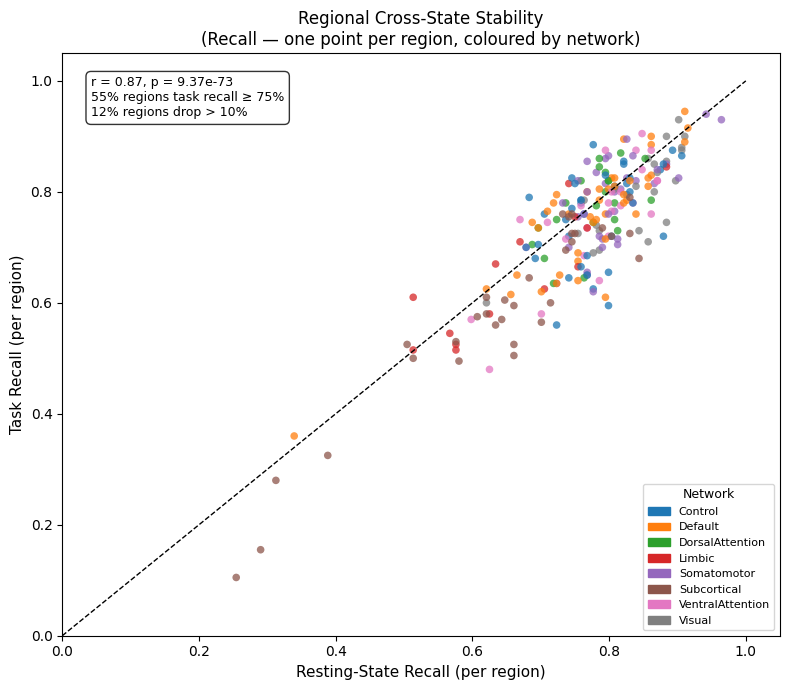

In [14]:
# ---------------------------------------------------------------------------
# Subcortical region indices (0-based): region IDs 200–231 from the atlas
# These 32 regions (16 right + 16 left) are collapsed into one 'Subcortical' group
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# Schaefer 7-Network mapping (collapsing 17 Yeo networks into 7)
# ---------------------------------------------------------------------------
SCHAEFER_7_MAPPING = {
    # Visual networks
    'VisCent': 'Visual',
    'VisPeri': 'Visual',
    # Somatomotor networks  
    'SomMotA': 'Somatomotor',
    'SomMotB': 'Somatomotor',
    # Dorsal Attention
    'DorsAttnA': 'DorsalAttention',
    'DorsAttnB': 'DorsalAttention',
    # Salience/Ventral Attention
    'SalVentAttnA': 'VentralAttention',
    'SalVentAttnB': 'VentralAttention',
    # Limbic
    'LimbicA': 'Limbic',
    'LimbicB': 'Limbic',
    # Control (formerly Cingulo-Opercular/Frontoparietal)
    'ContA': 'Control',
    'ContB': 'Control',
    'ContC': 'Control',
    # Default
    'DefaultA': 'Default',
    'DefaultB': 'Default',
    'DefaultC': 'Default',
    # Temporal-Parietal (often grouped with Default or kept separate, but in 7-network it's usually Default)
    'TempPar': 'Default',
}


SUBCORTICAL_IDS = set(range(200, 232))

# Step 1: resolve network labels from stability_df or rest_recall_df
net_col = next(
    (c for c in stability_df.columns if "network" in c.lower() or c.lower() == "net"),
    None
)

if net_col is not None:
    raw_network_labels = stability_df[net_col].values
else:
    net_col_src = next(
        (c for c in rest_recall_df.columns if "network" in c.lower()), None
    )
    raw_network_labels = (
        rest_recall_df[net_col_src].values if net_col_src
        else np.array(["Unknown"] * len(rest_recalls))
    )

# Step 2: identify the region_idx column to map subcortical IDs
idx_col_src = next(
    (c for c in stability_df.columns if "region" in c.lower() or "idx" in c.lower()),
    None
)
if idx_col_src is not None:
    region_ids = stability_df[idx_col_src].values
else:
    idx_col_rest = next(
        (c for c in rest_recall_df.columns if "region" in c.lower() or "idx" in c.lower()),
        None
    )
    region_ids = (
        rest_recall_df[idx_col_rest].values if idx_col_rest
        else np.arange(len(raw_network_labels))
    )

# Step 3: collapse networks
# First check if region is subcortical, then map to Schaefer 7 networks
def map_network(rid, net):
    if rid in SUBCORTICAL_IDS:
        return "Subcortical"
    return SCHAEFER_7_MAPPING.get(net, net)  # Fallback to original if not in mapping

network_labels = np.array([
    map_network(rid, net) for rid, net in zip(region_ids, raw_network_labels)
])

unique_networks = np.unique(network_labels)
print(f"Networks after grouping ({len(unique_networks)} total): {unique_networks.tolist()}")
print(f"Subcortical region count: {np.sum(network_labels == 'Subcortical')}  (expected 32)")

# Verify we have exactly 8 networks
assert len(unique_networks) == 8, f"Expected 8 networks, got {len(unique_networks)}"

# Step 4: assign one distinct colour per network (tab10 fits ≤10 networks cleanly)
cmap = plt.colormaps.get_cmap("tab10")
net_to_color = {net: cmap(i) for i, net in enumerate(unique_networks)}
point_colors = [net_to_color[n] for n in network_labels]

# Use r and p from JSON if available, else recomputed values
r_plot = r_json if r_json is not None else r_recomputed
p_r_plot = p_r_json if p_r_json is not None else p_r_recomputed
pct75_plot = pct_ge75 if pct_ge75 is not None else pct_ge75_recomputed
pctdrop_plot = pct_drop if pct_drop is not None else pct_drop_recomputed

# Step 5: plot
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(rest_recalls, task_recalls, c=point_colors, s=30, alpha=0.75, edgecolors="none")

# Diagonal (perfect preservation)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect preservation")

# Stat annotation box
p_str = f"{p_r_plot:.2e}" if isinstance(p_r_plot, float) else str(p_r_plot)
textstr = (
    f"r = {r_plot:.2f}, p = {p_str}\n"
    f"{pct75_plot:.0f}% regions task recall \u2265 75%\n"
    f"{pctdrop_plot:.0f}% regions drop > 10%"
)
ax.text(
    0.04, 0.96, textstr,
    transform=ax.transAxes, fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)

# Legend — 8 entries (7 cortical + 1 Subcortical)
legend_patches = [
    mpatches.Patch(color=net_to_color[net], label=net)
    for net in unique_networks
]
ax.legend(
    handles=legend_patches,
    title="Network",
    fontsize=8,
    title_fontsize=9,
    loc="lower right",
    ncol=1,
    framealpha=0.8
)

ax.set_xlabel("Resting-State Recall (per region)", fontsize=11)
ax.set_ylabel("Task Recall (per region)", fontsize=11)
ax.set_title(
    "Regional Cross-State Stability\n"
    "(Recall — one point per region, coloured by network)",
    fontsize=12
)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Cell 9 — Statistical Results Summary Table

In [10]:
stats_table = pd.DataFrame([
    {
        "Test"           : "Paired t-test (rest CV vs. task, per fold)",
        "Statistic"      : f"t({len(fold_metrics)-1}) = {t_stat:.1f}",
        "p-value"        : f"{p_val:.3e}",
        "Effect Size"    : f"Cohen's d = {cohens_d:.2f}",
        "Significant"    : "Yes" if p_val < 0.05 else "No"
    },
    {
        "Test"           : "Pearson r (rest vs. task per-region recall)",
        "Statistic"      : f"r = {r_plot:.2f}",
        "p-value"        : f"{p_str}",
        "Effect Size"    : "—",
        "Significant"    : "Yes" if (isinstance(p_r_plot, float) and p_r_plot < 0.05) else "See value"
    },
]).set_index("Test")

stats_table

,Statistic,p-value,Effect Size,Significant
Test,,,,
"Paired t-test (rest CV vs. task, per fold)",t(4) = 11.1,3.733e-04,Cohen's d = 4.97,Yes
Pearson r (rest vs. task per-region recall),r = 0.87,9.37e-73,—,Yes


## Cell 10 — Key Finding Summary

In [11]:
print("=" * 65)
print("KEY FINDING — H2: Cross-State Generalization")
print("=" * 65)
print()
print(f"  Resting-state fingerprints generalize robustly to task data.")
print(f"  Task accuracy: {task_acc*100:.2f}%  ({rel_retention:.1f}% of rest CV retained).")
print(f"  Both conditions far exceed chance ({CHANCE*100:.2f}%):")
print(f"    Rest: +{rest_vs_chance*100:.2f} pp  |  Task: +{task_vs_chance*100:.2f} pp")
print()
print(f"  Errors are near-miss: median correct rank = {median_rank:.1f}")
print(f"  (vs. chance median rank = {chance_median_rank:.1f}).")
print(f"  Top-5 accuracy: {top5_acc*100:.2f}%  |  Top-10: {top10_acc*100:.2f}%")
print()
print(f"  The rest→task drop is small but systematic:")
print(f"    t({len(fold_metrics)-1}) = {t_stat:.1f}, p = {p_val:.3e}, Cohen's d = {cohens_d:.2f}")
print()
print(f"  Regional identifiability is strongly preserved:")
print(f"    Pearson r (rest vs. task recall) = {r_plot:.2f}")
print(f"    {pct75_plot:.0f}% of regions maintain task recall ≥ 75%")
print(f"    {pctdrop_plot:.0f}% of regions show drop > 10% (heterogeneity)")
print()
print("  → H2 CONFIRMED: Fingerprints generalize; modest systematic")
print("    drop and regional heterogeneity support partial reorganization.")
print("=" * 65)

KEY FINDING — H2: Cross-State Generalization

  Resting-state fingerprints generalize robustly to task data.
  Task accuracy: 73.04%  (95.8% of rest CV retained).
  Both conditions far exceed chance (0.43%):
    Rest: +75.81 pp  |  Task: +72.61 pp

  Errors are near-miss: median correct rank = 1.0
  (vs. chance median rank = 116.5).
  Top-5 accuracy: 85.63%  |  Top-10: 90.20%

  The rest→task drop is small but systematic:
    t(4) = 11.1, p = 3.733e-04, Cohen's d = 4.97

  Regional identifiability is strongly preserved:
    Pearson r (rest vs. task recall) = 0.87
    55% of regions maintain task recall ≥ 75%
    12% of regions show drop > 10% (heterogeneity)

  → H2 CONFIRMED: Fingerprints generalize; modest systematic
    drop and regional heterogeneity support partial reorganization.
